In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as effnet_preprocess
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: []


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
PROJECT_ROOT = ROOT / "19042026"

E00_ROOT = PROJECT_ROOT / "E00_hyperparameter_tuning"
E02_ROOT = PROJECT_ROOT / "E02_class_imbalance"
E03_ROOT = PROJECT_ROOT / "E03_augmentation_overfitting"
E04_ROOT = PROJECT_ROOT / "E04_finetuning_depth"
EXP_ROOT = PROJECT_ROOT / "E05_architecture_comparison"

IMG_SIZE = (224, 224)
THRESHOLD = 0.50
BATCH_EXTRACT = 16

USE_HAIR_REMOVAL = True
USE_SEGMENTATION = True
USE_AUGMENTATION = True
AUG_MODE = "strong"

RUNS = [
    {
        "run_name": "E05_resnet50",
        "arch": "resnet50",
        "reuse_e03_cache": True
    },
    {
        "run_name": "E05_efficientnetb0",
        "arch": "efficientnetb0",
        "reuse_e03_cache": False
    },
    {
        "run_name": "E05_densenet121",
        "arch": "densenet121",
        "reuse_e03_cache": False
    }
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("E00_ROOT:", E00_ROOT)
print("E02_ROOT:", E02_ROOT)
print("E03_ROOT:", E03_ROOT)
print("E04_ROOT:", E04_ROOT)
print("EXP_ROOT:", EXP_ROOT)

PROJECT_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026
E00_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E00_hyperparameter_tuning
E02_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E02_class_imbalance
E03_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E03_augmentation_overfitting
E04_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E04_finetuning_depth
EXP_ROOT: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\E05_architecture_comparison


In [3]:
SUBDIRS = [
    "configs",
    "models",
    "histories",
    "metrics",
    "predictions",
    "plots",
    "confusion_matrices",
    "feature_cache",
    "logs",
    "summary",
    "preprocessing_samples"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

for run in RUNS:
    run_name = run["run_name"]
    for sub in ["models", "histories", "metrics", "predictions", "plots", "confusion_matrices", "feature_cache"]:
        (EXP_ROOT / sub / run_name).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [4]:
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def verify_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def remove_hairs_bgr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img_bgr, mask, 1, cv2.INPAINT_TELEA)
    return cleaned, mask

def simple_segment_lesion(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_bgr, thresh

    largest = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    x, y, w, h = cv2.boundingRect(largest)
    crop = segmented[y:y+h, x:x+w] if w > 0 and h > 0 else segmented
    return crop, mask

def apply_augmentation(img_rgb, mode="strong"):
    h, w = img_rgb.shape[:2]

    if random.random() < 0.5:
        img_rgb = cv2.flip(img_rgb, 1)

    if mode == "strong":
        angle = random.uniform(-30, 30)
        scale = random.uniform(0.85, 1.15)
        tx = random.uniform(-0.08*w, 0.08*w)
        ty = random.uniform(-0.08*h, 0.08*h)
        alpha = random.uniform(0.85, 1.15)
        beta = random.uniform(-20, 20)
    else:
        angle = random.uniform(-20, 20)
        scale = random.uniform(0.90, 1.10)
        tx = random.uniform(-0.05*w, 0.05*w)
        ty = random.uniform(-0.05*h, 0.05*h)
        alpha = random.uniform(0.90, 1.10)
        beta = random.uniform(-15, 15)

    M = cv2.getRotationMatrix2D((w//2, h//2), angle, scale)
    M[:, 2] += [tx, ty]
    img_rgb = cv2.warpAffine(img_rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    img_rgb = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)
    return img_rgb

def get_preprocess_fn(arch):
    if arch == "resnet50":
        return resnet_preprocess
    elif arch == "efficientnetb0":
        return effnet_preprocess
    elif arch == "densenet121":
        return densenet_preprocess
    else:
        raise ValueError(f"Unsupported architecture: {arch}")

def preprocess_image_for_model(path, arch, img_size=(224, 224), use_hair_removal=True,
                               use_segmentation=True, use_aug=False, aug_mode="strong"):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    original = img_bgr.copy()
    hair_mask = None
    seg_mask = None

    if use_hair_removal:
        img_bgr, hair_mask = remove_hairs_bgr(img_bgr)

    if use_segmentation:
        img_bgr, seg_mask = simple_segment_lesion(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, img_size, interpolation=cv2.INTER_AREA)

    if use_aug:
        img_rgb = apply_augmentation(img_rgb, mode=aug_mode)

    img_arr = np.asarray(img_rgb, dtype=np.float32)
    preprocess_fn = get_preprocess_fn(arch)
    img_arr = preprocess_fn(img_arr)

    return img_arr, original, hair_mask, seg_mask

def evaluate_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "kappa": float(kappa),
        "roc_auc": float(roc) if not np.isnan(roc) else None,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }

def plot_confusion(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = ["Non-Melanoma", "Melanoma"]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_history(history, save_dir, run_name):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_accuracy.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

def plot_roc_pr(y_true, y_prob, save_dir, run_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_roc.png", dpi=300, bbox_inches="tight")
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{run_name}_pr.png", dpi=300, bbox_inches="tight")
    plt.close()

In [5]:
best_cfg = load_json(E00_ROOT / "summary" / "best_config.json")
best_hparams = best_cfg["best_config"]

best_e02 = load_json(E02_ROOT / "summary" / "best_E02_variant.json")
best_e03 = load_json(E03_ROOT / "summary" / "best_E03_variant.json")
best_e04 = load_json(E04_ROOT / "summary" / "best_E04_variant.json")
manifest_e02 = load_json(E02_ROOT / "summary" / "experiment_manifest.json")

cb_class_weights = {int(k): float(v) for k, v in manifest_e02["class_balanced_weights"].items()}

train_df = pd.read_csv(E00_ROOT / "summary" / "train_split.csv")
val_df   = pd.read_csv(E00_ROOT / "summary" / "val_split.csv")
test_df  = pd.read_csv(E00_ROOT / "summary" / "test_split.csv")

train_df["image_path"] = train_df["image_path"].apply(Path)
val_df["image_path"] = val_df["image_path"].apply(Path)
test_df["image_path"] = test_df["image_path"].apply(Path)

print("Best E00 config:")
print(json.dumps(best_cfg, indent=4))

print("\nBest E02 variant:")
print(json.dumps(best_e02, indent=4))

print("\nBest E03 variant:")
print(json.dumps(best_e03, indent=4))

print("\nBest E04 variant:")
print(json.dumps(best_e04, indent=4))

print("\nUsing class-balanced weights from E02:")
print(cb_class_weights)

Best E00 config:
{
    "best_by": "f1",
    "sort_column": "test_f1",
    "best_run_name": "run_004_du256_do04_lr5e-05_bs16",
    "best_config": {
        "dense_units": 256,
        "dropout": 0.4,
        "lr": 5e-05,
        "batch_size": 16,
        "epochs": 15
    },
    "best_test_metrics": {
        "accuracy": 0.982874617737003,
        "precision": 0.75,
        "recall": 0.05172413793103448,
        "f1": 0.0967741935483871,
        "kappa": 0.0947022879629813,
        "roc_auc": 0.8362176321552798,
        "tn": 3211,
        "fp": 1,
        "fn": 55,
        "tp": 3
    }
}

Best E02 variant:
{
    "run_name": "E02_class_balanced_bce",
    "mode": "class_balanced_bce",
    "source_e01_run": "E01b_baseline_segmented",
    "accuracy": 0.9596330275229358,
    "precision": 0.12244897959183673,
    "recall": 0.20689655172413793,
    "f1": 0.15384615384615385,
    "kappa": 0.1345598614140896,
    "roc_auc": 0.8305707046850174,
    "tn": 3126,
    "fp": 86,
    "fn": 46,
    "tp

In [6]:
sample_df = train_df.sample(min(6, len(train_df)), random_state=SEED)

for run in RUNS:
    run_name = run["run_name"]
    arch = run["arch"]

    out_dir = EXP_ROOT / "preprocessing_samples" / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    for idx, row in sample_df.iterrows():
        _, original_bgr, hair_mask, seg_mask = preprocess_image_for_model(
            row["image_path"],
            arch=arch,
            img_size=IMG_SIZE,
            use_hair_removal=USE_HAIR_REMOVAL,
            use_segmentation=USE_SEGMENTATION,
            use_aug=True,
            aug_mode=AUG_MODE
        )

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(hair_mask, cmap="gray")
        axes[1].set_title("Hair Mask")
        axes[1].axis("off")

        axes[2].imshow(seg_mask, cmap="gray")
        axes[2].set_title("Segmentation Mask")
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(out_dir / f"sample_{idx}.png", dpi=300, bbox_inches="tight")
        plt.close()

In [7]:
def build_feature_extractor(arch):
    if arch == "resnet50":
        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            pooling="avg",
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )
    elif arch == "efficientnetb0":
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            pooling="avg",
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )
    elif arch == "densenet121":
        base_model = DenseNet121(
            weights="imagenet",
            include_top=False,
            pooling="avg",
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )
    else:
        raise ValueError(f"Unsupported architecture: {arch}")

    base_model.trainable = False
    return base_model

In [8]:
def load_e03_resnet_cache(split_name):
    cache_dir = E03_ROOT / "feature_cache" / best_e03["run_name"]
    cache_x = cache_dir / f"X_{split_name}.npy"
    cache_y = cache_dir / f"y_{split_name}.npy"

    if not cache_x.exists() or not cache_y.exists():
        raise FileNotFoundError(f"E03 ResNet cache missing for split={split_name}")

    print(f"[REUSE E03 CACHE] resnet50 -> {split_name}")
    return np.load(cache_x), np.load(cache_y)

def extract_features(df_split, split_name, run_name, arch, base_model, use_aug=False):
    cache_dir = EXP_ROOT / "feature_cache" / run_name
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_x = cache_dir / f"X_{split_name}.npy"
    cache_y = cache_dir / f"y_{split_name}.npy"

    if cache_x.exists() and cache_y.exists():
        print(f"[CACHE] {run_name} -> {split_name}")
        return np.load(cache_x), np.load(cache_y)

    print(f"[EXTRACT] {run_name} -> {split_name}")

    feature_batches = []
    label_batches = []

    batch_images = []
    batch_labels = []

    for i, (_, row) in enumerate(df_split.iterrows(), start=1):
        img_arr, _, _, _ = preprocess_image_for_model(
            row["image_path"],
            arch=arch,
            img_size=IMG_SIZE,
            use_hair_removal=USE_HAIR_REMOVAL,
            use_segmentation=USE_SEGMENTATION,
            use_aug=use_aug,
            aug_mode=AUG_MODE
        )

        batch_images.append(img_arr)
        batch_labels.append(row["target"])

        if len(batch_images) == BATCH_EXTRACT:
            batch_images_np = np.array(batch_images, dtype=np.float32)
            batch_features = base_model.predict(batch_images_np, batch_size=BATCH_EXTRACT, verbose=0)

            feature_batches.append(batch_features)
            label_batches.append(np.array(batch_labels, dtype=np.int32))

            batch_images = []
            batch_labels = []

            if i % (BATCH_EXTRACT * 50) == 0:
                print(f"Processed {i}/{len(df_split)} images for {run_name} - {split_name}")

    if len(batch_images) > 0:
        batch_images_np = np.array(batch_images, dtype=np.float32)
        batch_features = base_model.predict(batch_images_np, batch_size=BATCH_EXTRACT, verbose=0)

        feature_batches.append(batch_features)
        label_batches.append(np.array(batch_labels, dtype=np.int32))

    X = np.concatenate(feature_batches, axis=0)
    y = np.concatenate(label_batches, axis=0)

    np.save(cache_x, X)
    np.save(cache_y, y)

    return X, y

In [9]:
def build_head_model(feature_dim, dense_units, dropout, lr):
    model = keras.Sequential([
        layers.Input(shape=(feature_dim,)),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [10]:
all_results = []

for run in RUNS:
    run_name = run["run_name"]
    arch = run["arch"]
    reuse_e03_cache = run["reuse_e03_cache"]

    print("\n" + "=" * 90)
    print("Running:", run_name)
    print("Architecture:", arch)
    print("Reuse E03 cache:", reuse_e03_cache)

    run_start = time.time()

    if reuse_e03_cache and arch == "resnet50":
        X_train, y_train = load_e03_resnet_cache("train")
        X_val, y_val     = load_e03_resnet_cache("val")
        X_test, y_test   = load_e03_resnet_cache("test")
    else:
        base_model = build_feature_extractor(arch)

        X_train, y_train = extract_features(
            train_df, "train", run_name, arch, base_model, use_aug=True
        )

        X_val, y_val = extract_features(
            val_df, "val", run_name, arch, base_model, use_aug=False
        )

        X_test, y_test = extract_features(
            test_df, "test", run_name, arch, base_model, use_aug=False
        )

    model = build_head_model(
        feature_dim=X_train.shape[1],
        dense_units=best_hparams["dense_units"],
        dropout=best_hparams["dropout"],
        lr=best_hparams["lr"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=best_hparams["epochs"],
        batch_size=best_hparams["batch_size"],
        verbose=1,
        callbacks=callbacks,
        class_weight=cb_class_weights
    )

    runtime_sec = time.time() - run_start

    model.save(EXP_ROOT / "models" / run_name / f"{run_name}.keras")

    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(EXP_ROOT / "histories" / run_name / f"{run_name}_history.csv", index=False)
    plot_history(history, EXP_ROOT / "plots" / run_name, run_name)

    y_val_prob = model.predict(X_val, batch_size=best_hparams["batch_size"], verbose=0).ravel()
    y_test_prob = model.predict(X_test, batch_size=best_hparams["batch_size"], verbose=0).ravel()

    val_metrics = evaluate_binary(y_val, y_val_prob, threshold=THRESHOLD)
    test_metrics = evaluate_binary(y_test, y_test_prob, threshold=THRESHOLD)

    pred_df = pd.DataFrame({
        "image_name": test_df["image_name"].values,
        "true_label": y_test,
        "pred_prob": y_test_prob,
        "pred_label": (y_test_prob >= THRESHOLD).astype(int)
    })
    pred_df.to_csv(EXP_ROOT / "predictions" / run_name / f"{run_name}_test_predictions.csv", index=False)

    metrics_package = {
        "run_name": run_name,
        "architecture": arch,
        "reuse_e03_cache": reuse_e03_cache,
        "source_e03_run": best_e03["run_name"],
        "source_e04_run": best_e04["run_name"],
        "best_hyperparameters_from_E00": best_hparams,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "runtime_sec": round(runtime_sec, 2)
    }
    save_json(metrics_package, EXP_ROOT / "metrics" / run_name / f"{run_name}_metrics.json")

    cm = confusion_matrix(y_test, (y_test_prob >= THRESHOLD).astype(int), labels=[0, 1])
    plot_confusion(
        cm,
        title=f"Confusion Matrix - {run_name}",
        save_path=EXP_ROOT / "confusion_matrices" / run_name / f"{run_name}_cm.png"
    )

    plot_roc_pr(y_test, y_test_prob, EXP_ROOT / "plots" / run_name, run_name)

    row = {
        "run_name": run_name,
        "architecture": arch,
        "reuse_e03_cache": reuse_e03_cache,
        "source_e03_run": best_e03["run_name"],
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "kappa": test_metrics["kappa"],
        "roc_auc": test_metrics["roc_auc"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "runtime_sec": round(runtime_sec, 2)
    }
    all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df.to_csv(EXP_ROOT / "summary" / "E05_results_comparison.csv", index=False)
results_df


Running: E05_resnet50
Architecture: resnet50
Reuse E03 cache: True
[REUSE E03 CACHE] resnet50 -> train
[REUSE E03 CACHE] resnet50 -> val
[REUSE E03 CACHE] resnet50 -> test
Epoch 1/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8550 - loss: 0.0810 - val_accuracy: 0.9511 - val_loss: 0.1765
Epoch 2/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8778 - loss: 0.0605 - val_accuracy: 0.9547 - val_loss: 0.1761
Epoch 3/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8973 - loss: 0.0547 - val_accuracy: 0.9563 - val_loss: 0.1749
Epoch 4/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9010 - loss: 0.0513 - val_accuracy: 0.9627 - val_loss: 0.1479
Epoch 5/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9031 - loss: 0.0494 - val_accuracy: 0.9578 - val_loss: 0.1591
Epoch 6/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9098 - loss: 0.0456 - val_accuracy: 0.9550 - val_loss: 0.1616
Epoch 7/15
1635/1635 ━━━━━━━━━━━━━━━━━━━━

,run_name,architecture,reuse_e03_cache,source_e03_run,accuracy,precision,recall,f1,kappa,roc_auc,tn,fp,fn,tp,runtime_sec
0,E05_resnet50,resnet50,True,E03_aug_strong,0.959021,0.112245,0.189655,0.141026,0.121447,0.838955,3125,87,47,11,90.09
1,E05_efficientnetb0,efficientnetb0,False,E03_aug_strong,0.972783,0.081081,0.051724,0.063158,0.050033,0.823995,3178,34,55,3,23546.84
2,E05_densenet121,densenet121,False,E03_aug_strong,0.969725,0.113208,0.103448,0.108108,0.092741,0.786195,3165,47,52,6,25985.17


In [11]:
results_sorted = results_df.sort_values(by=["f1", "recall", "kappa"], ascending=False).reset_index(drop=True)
best_e05 = results_sorted.iloc[0].to_dict()

save_json(best_e05, EXP_ROOT / "summary" / "best_E05_variant.json")

print("Best E05 variant:")
print(json.dumps(best_e05, indent=4))

Best E05 variant:
{
    "run_name": "E05_resnet50",
    "architecture": "resnet50",
    "reuse_e03_cache": true,
    "source_e03_run": "E03_aug_strong",
    "accuracy": 0.9590214067278288,
    "precision": 0.11224489795918367,
    "recall": 0.1896551724137931,
    "f1": 0.14102564102564102,
    "kappa": 0.12144713204157576,
    "roc_auc": 0.838955211061966,
    "tn": 3125,
    "fp": 87,
    "fn": 47,
    "tp": 11,
    "runtime_sec": 90.09
}


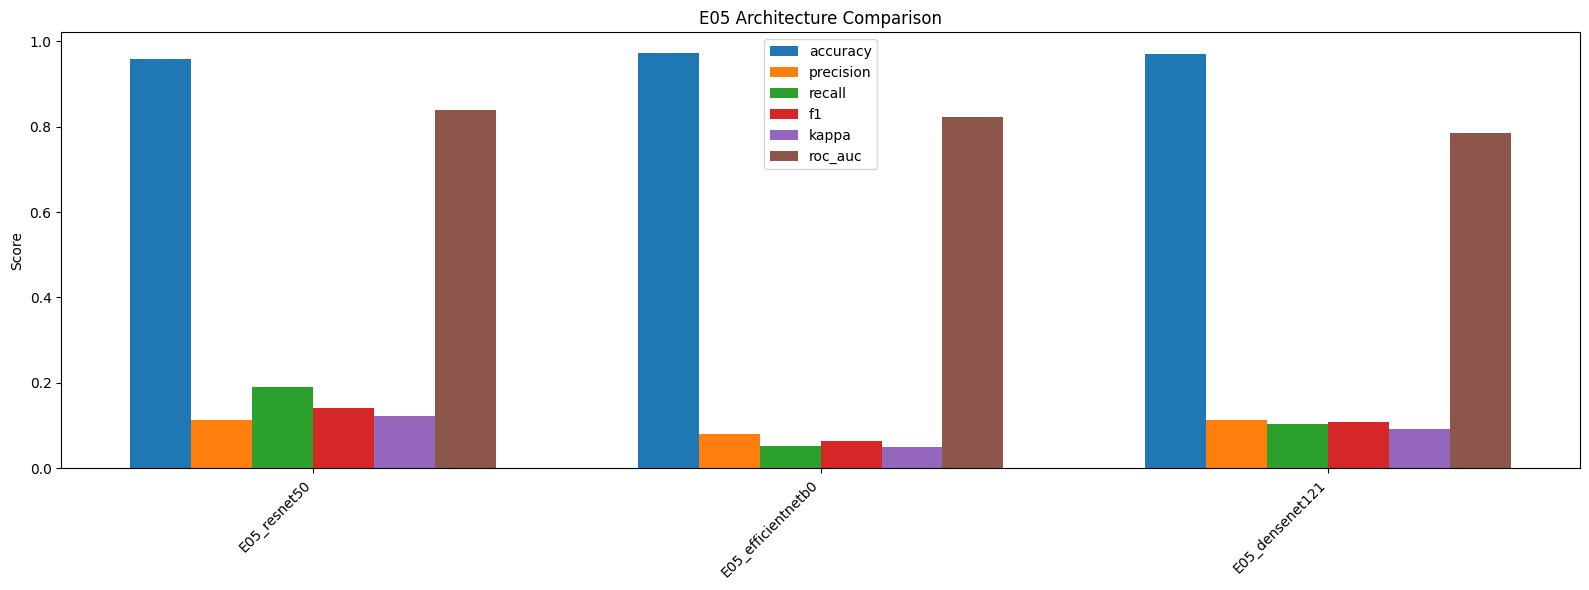

In [12]:
if len(results_df) > 0:
    plot_cols = ["accuracy", "precision", "recall", "f1", "kappa", "roc_auc"]
    plot_df = results_df[["run_name"] + plot_cols].copy()

    x = np.arange(len(plot_df))
    width = 0.12

    plt.figure(figsize=(16, 6))
    for idx, col in enumerate(plot_cols):
        plt.bar(x + idx * width, plot_df[col].fillna(0), width=width, label=col)

    plt.xticks(x + width * (len(plot_cols)-1) / 2, plot_df["run_name"], rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title("E05 Architecture Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXP_ROOT / "plots" / "E05_metrics_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
manifest = {
    "experiment_id": "E05",
    "experiment_name": "Architecture Comparison",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "experiment_root": str(EXP_ROOT),
    "source_e02_run": best_e02["run_name"],
    "source_e03_run": best_e03["run_name"],
    "source_e04_run": best_e04["run_name"],
    "best_hyperparameters_from_E00": best_hparams,
    "class_balanced_weights_from_E02": cb_class_weights,
    "threshold": THRESHOLD,
    "use_hair_removal": USE_HAIR_REMOVAL,
    "use_segmentation": USE_SEGMENTATION,
    "use_augmentation": USE_AUGMENTATION,
    "augmentation_mode": AUG_MODE,
    "img_size": IMG_SIZE,
    "batch_extract": BATCH_EXTRACT,
    "runs": RUNS,
    "note": "ResNet50 reuses E03 cached features for time efficiency; EfficientNetB0 and DenseNet121 are extracted freshly under the same best pipeline."
}
save_json(manifest, EXP_ROOT / "summary" / "experiment_manifest.json")
print("E05 finished.")

E05 finished.
